## Installation

``` bash
conda create -n spaflow python=3.10 -y
pip install spaflow
```

## Load spatial transcriptomics data

In [1]:
import warnings
warnings.filterwarnings("ignore")
import scanpy as sc
from spaflow import filter_lr_database, run_spaflow

In [2]:
adata = sc.read("/fs/ess/PAS1475/huchen/spaflow/example_data/example_data.h5ad")
df_ligrec = filter_lr_database(adata) # only keep screated signaling 
df_ligrec.head()

,ligand,receptor,pathway,integrated_pathway,signaling type,complex
0,TGFB1,TGFBR1_TGFBR2,TGFb,ACTIVIN_GDF_TGFb,Secreted Signaling,TGFB1-TGFBR1_TGFBR2
2,TGFB3,TGFBR1_TGFBR2,TGFb,ACTIVIN_GDF_TGFb,Secreted Signaling,TGFB3-TGFBR1_TGFBR2
4,TGFB1,ACVR1B_TGFBR2,TGFb,ACTIVIN_GDF_TGFb,Secreted Signaling,TGFB1-ACVR1B_TGFBR2
6,TGFB3,ACVR1B_TGFBR2,TGFb,ACTIVIN_GDF_TGFb,Secreted Signaling,TGFB3-ACVR1B_TGFBR2
8,GDF15,TGFBR2,GDF,ACTIVIN_GDF_TGFb,Secreted Signaling,GDF15-TGFBR2


## Run SpaFlow

In [14]:
spaflow_adata = run_spaflow(adata, df_ligrec)

## Show the results
* Ligand-receptor interaction (LRI) activity
* LRI hotspots

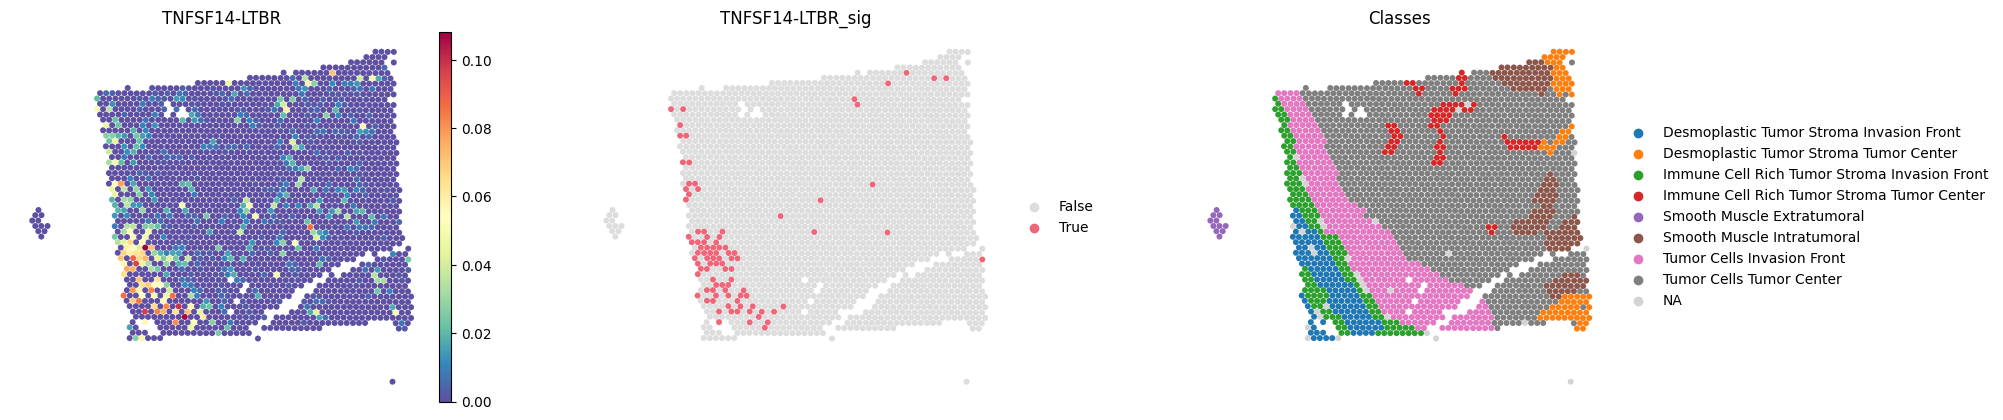

In [15]:
lr = 'TNFSF14-LTBR'
spaflow_adata.uns[f'{lr}_sig_colors'] = ["#DDDDDD", "#EE6677"]
sc.pl.spatial(spaflow_adata, color=[lr, f"{lr}_sig", 'Classes'], img_key=None, size=1.5, frameon=False, cmap='Spectral_r')